In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
ny = pd.read_csv(r"C:\Users\hp\Downloads\New York DS.csv")
bangkok = pd.read_csv(r"c:\Users\hp\Downloads\Bangkok.csv")

In [4]:
from sqlalchemy import create_engine

user = 'postgres'
password = '12345qwerty'
host = 'localhost'  
port = '5432'       
database = 'airbnb'
engine = create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}")

table_name = 'bangkok_listings'
bangkok.to_sql(table_name,engine,if_exists='replace',index=False)
print(f"Data successfully loaded into table '{table_name}' in  database '{database}'")

Data successfully loaded into table 'bangkok_listings' in  database 'airbnb'


In [5]:
from sqlalchemy import create_engine

user = 'postgres'
password = '12345qwerty'
host = 'localhost'  
port = '5432'       
database = 'airbnb'
engine = create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}")

table_name = 'ny_listings'
ny.to_sql(table_name,engine,if_exists='replace',index=False)
print(f"Data successfully loaded into table '{table_name}' in  database '{database}'")

Data successfully loaded into table 'ny_listings' in  database 'airbnb'


In [6]:
print("New York shape:", ny.shape)
print("Bangkok shape:", bangkok.shape)

print("\nNew York columns:", ny.columns.tolist())
print("\nBangkok columns:", bangkok.columns.tolist())

New York shape: (30555, 19)
Bangkok shape: (31069, 19)

New York columns: ['id', 'name', 'host_id', 'host_profile_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'license']

Bangkok columns: ['id', 'name', 'host_id', 'host_profile_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'license']


In [7]:
print(ny.isnull().sum())


id                                    0
name                                  1
host_id                             296
host_profile_id                     645
host_name                           645
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                              8758
minimum_nights                        2
number_of_reviews                     0
last_review                        8616
reviews_per_month                  8616
calculated_host_listings_count      296
availability_365                      0
number_of_reviews_ltm                 0
license                           25269
dtype: int64


In [8]:
print(bangkok.isnull().sum())


id                                    0
name                                  0
host_id                               0
host_profile_id                       2
host_name                             0
neighbourhood_group               31069
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                              2082
minimum_nights                        2
number_of_reviews                     0
last_review                       10253
reviews_per_month                 10253
calculated_host_listings_count        0
availability_365                      0
number_of_reviews_ltm                 0
license                           31069
dtype: int64


In [9]:
ny.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30555 entries, 0 to 30554
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              30555 non-null  int64  
 1   name                            30554 non-null  object 
 2   host_id                         30259 non-null  float64
 3   host_profile_id                 29910 non-null  float64
 4   host_name                       29910 non-null  object 
 5   neighbourhood_group             30555 non-null  object 
 6   neighbourhood                   30555 non-null  object 
 7   latitude                        30555 non-null  float64
 8   longitude                       30555 non-null  float64
 9   room_type                       30555 non-null  object 
 10  price                           21797 non-null  float64
 11  minimum_nights                  30553 non-null  float64
 12  number_of_reviews               

In [10]:
bangkok.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31069 entries, 0 to 31068
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              31069 non-null  int64  
 1   name                            31069 non-null  object 
 2   host_id                         31069 non-null  int64  
 3   host_profile_id                 31067 non-null  float64
 4   host_name                       31069 non-null  object 
 5   neighbourhood_group             0 non-null      float64
 6   neighbourhood                   31069 non-null  object 
 7   latitude                        31069 non-null  float64
 8   longitude                       31069 non-null  float64
 9   room_type                       31069 non-null  object 
 10  price                           28987 non-null  float64
 11  minimum_nights                  31067 non-null  float64
 12  number_of_reviews               

In [11]:
bangkok['price'].mean()

np.float64(2955.9828543829994)

In [12]:
ny['price'].mean()

np.float64(278.3259622883883)

In [13]:
#fix price column (remove $ sign and convert to numeric)

ny['price'] = pd.to_numeric(ny['price'], errors='coerce')
bangkok['price'] = pd.to_numeric(bangkok['price'], errors='coerce')

In [14]:
#  fill missing reviews_per_month with 0
ny['reviews_per_month'] = ny['reviews_per_month'].fillna(0)
bangkok['reviews_per_month'] = bangkok['reviews_per_month'].fillna(0)

In [15]:
#  drop rows where price is null or 0
ny = ny[ny['price'] > 0]
bangkok = bangkok[bangkok['price'] > 0]

In [16]:
# fix last_review to datetime
ny['last_review'] = pd.to_datetime(ny['last_review'])
bangkok['last_review'] = pd.to_datetime(bangkok['last_review'])

In [17]:
#  add city column (useful for combined charts)
ny['city'] = 'New York'
bangkok['city'] = 'Bangkok'

In [18]:
#  combine both datasets
combined = pd.concat([ny, bangkok], ignore_index=True)

In [19]:
# verify
print("\nAfter cleaning:")
print("New York rows:", len(ny))
print("Bangkok rows:", len(bangkok))
print("Combined rows:", len(combined))


After cleaning:
New York rows: 21797
Bangkok rows: 28987
Combined rows: 50784


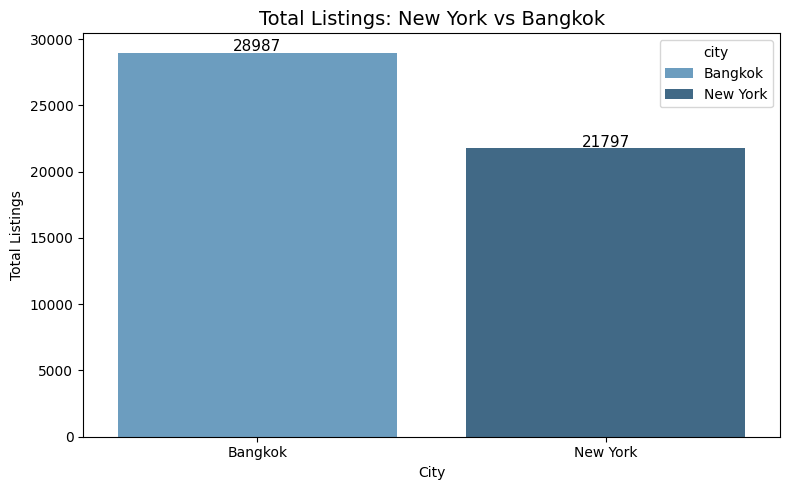

In [20]:
plt.figure(figsize=(8,5))
city_counts = combined.groupby('city')['id'].count().reset_index()
city_counts.columns = ['city','total_listings']

sns.barplot(data=city_counts, x='city', y='total_listings', hue='city', palette='Blues_d', legend=True)
plt.title('Total Listings: New York vs Bangkok', fontsize=14)
plt.xlabel('City')
plt.ylabel('Total Listings')
for i, row in city_counts.iterrows():
    plt.text(i, row['total_listings']+100, str(row['total_listings']), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('viz1_total_listings.png', dpi=150)
plt.show()

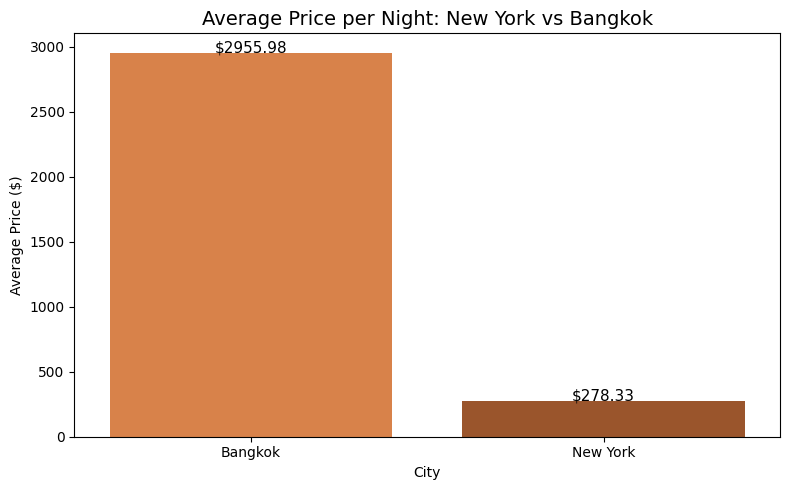

In [21]:
plt.figure(figsize=(8,5))
avg_price = combined.groupby('city')['price'].mean().reset_index()
avg_price.columns = ['city','avg_price']
avg_price['avg_price'] = avg_price['avg_price'].round(2)

sns.barplot(data=avg_price, x='city', y='avg_price',
            hue='city', palette='Oranges_d', legend=False)
plt.title('Average Price per Night: New York vs Bangkok', fontsize=14)
plt.xlabel('City')
plt.ylabel('Average Price ($)')
for i, row in avg_price.iterrows():
    plt.text(i, row['avg_price']+1, f"${row['avg_price']}", ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('viz2_avg_price.png', dpi=150)
plt.show()

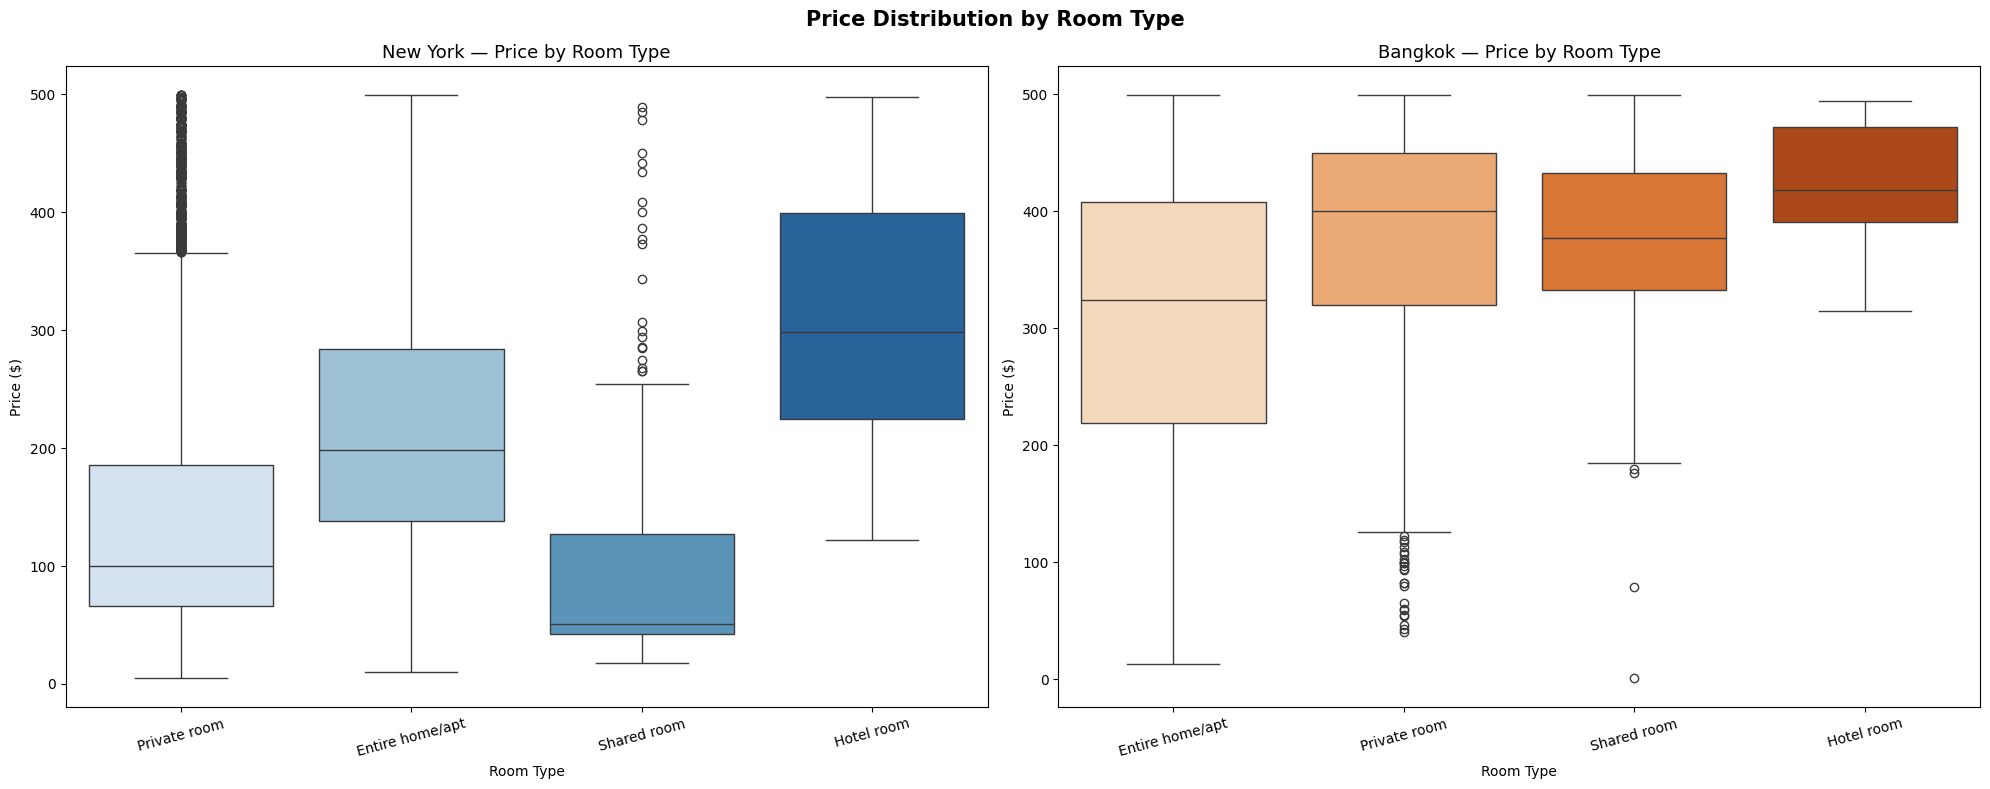

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# New York
ny_filtered = ny[ny['price'] < 500]  # remove extreme outliers for better view
axes[0].set_title('New York — Price by Room Type', fontsize=13)
sns.boxplot(data=ny_filtered, x='room_type', y='price', 
            hue='room_type', palette='Blues', legend=False, ax=axes[0])
axes[0].set_xlabel('Room Type')
axes[0].set_ylabel('Price ($)')
axes[0].tick_params(axis='x', rotation=15)

# Bangkok
bangkok_filtered = bangkok[bangkok['price'] < 500]
axes[1].set_title('Bangkok — Price by Room Type', fontsize=13)
sns.boxplot(data=bangkok_filtered, x='room_type', y='price',
            hue='room_type', palette='Oranges', legend=False, ax=axes[1])
axes[1].set_xlabel('Room Type')
axes[1].set_ylabel('Price ($)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Price Distribution by Room Type', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('viz3_price_roomtype.png', dpi=150)
plt.show()

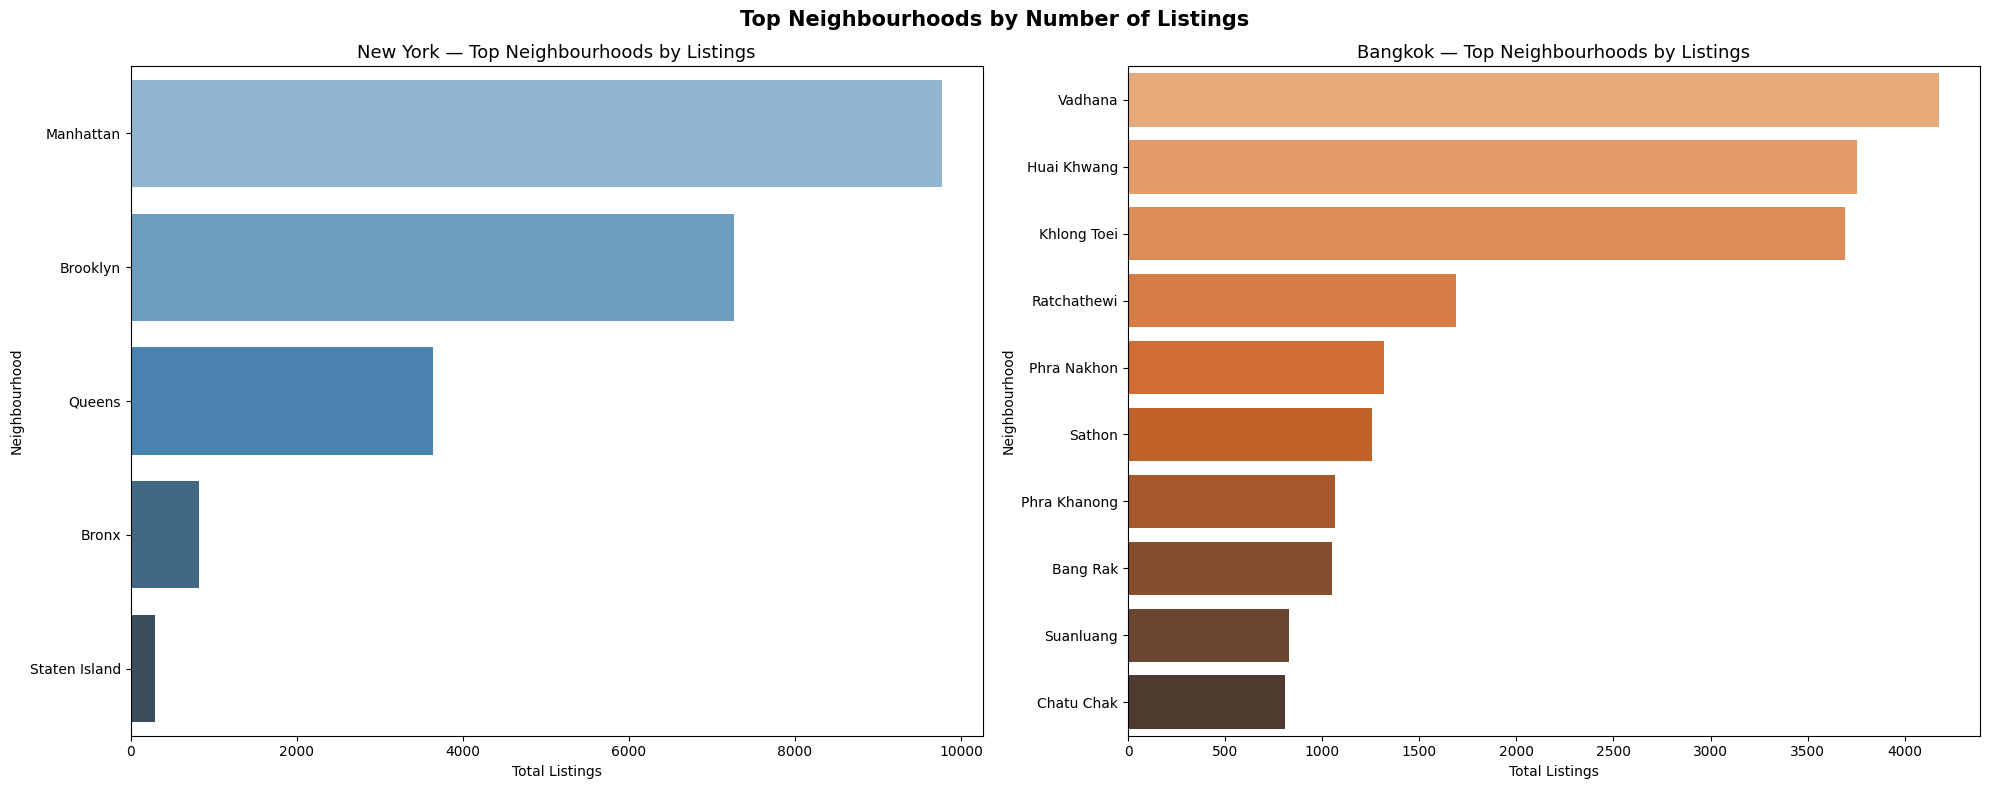

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# New York
ny_neigh = ny.groupby('neighbourhood_group')['id'].count().reset_index()
ny_neigh.columns = ['neighbourhood','count']
ny_neigh = ny_neigh.sort_values('count', ascending=False).head(10)

sns.barplot(data=ny_neigh, x='count', y='neighbourhood',
            hue='neighbourhood', palette='Blues_d', legend=False, ax=axes[0])
axes[0].set_title('New York — Top Neighbourhoods by Listings', fontsize=13)
axes[0].set_xlabel('Total Listings')
axes[0].set_ylabel('Neighbourhood')

# Bangkok
bangkok_neigh = bangkok.groupby('neighbourhood')['id'].count().reset_index()
bangkok_neigh.columns = ['neighbourhood','count']
bangkok_neigh = bangkok_neigh.sort_values('count', ascending=False).head(10)

sns.barplot(data=bangkok_neigh, x='count', y='neighbourhood',
            hue='neighbourhood', palette='Oranges_d', legend=False, ax=axes[1])
axes[1].set_title('Bangkok — Top Neighbourhoods by Listings', fontsize=13)
axes[1].set_xlabel('Total Listings')
axes[1].set_ylabel('Neighbourhood')

plt.suptitle('Top Neighbourhoods by Number of Listings', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('viz4_top_neighbourhoods.png', dpi=150)
plt.show()

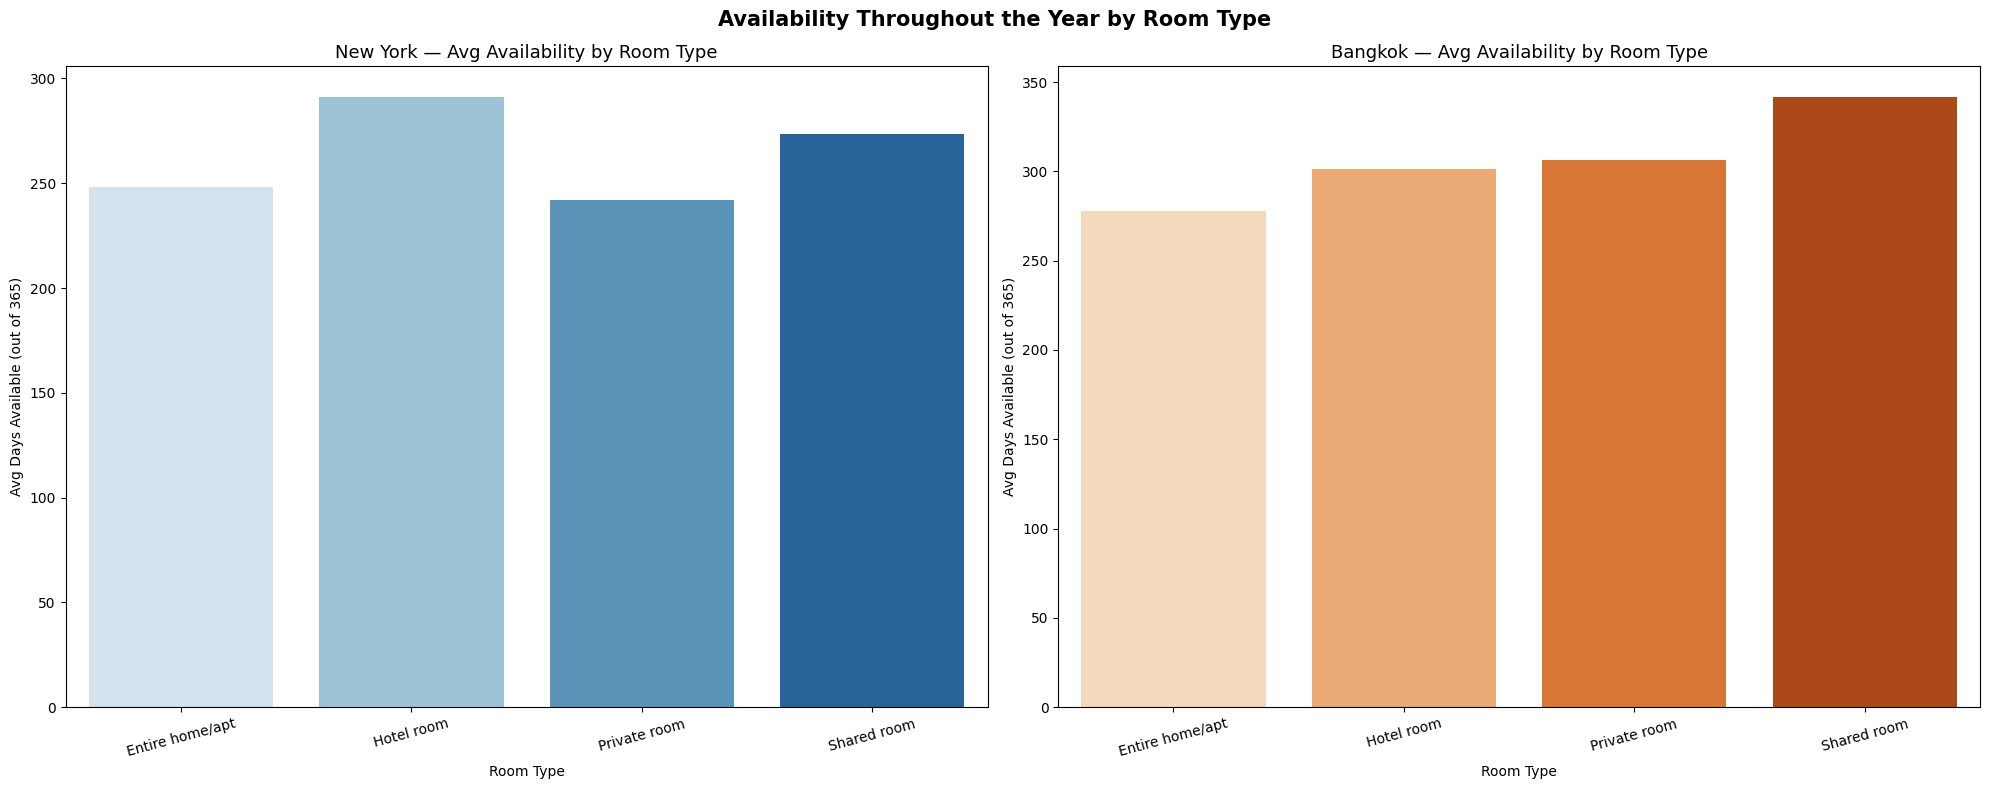

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

ny_avail = ny.groupby('room_type')['availability_365'].mean().reset_index()
ny_avail.columns = ['room_type','avg_availability']

sns.barplot(data=ny_avail, x='room_type', y='avg_availability',
            hue='room_type', palette='Blues', legend=False, ax=axes[0])
axes[0].set_title('New York — Avg Availability by Room Type', fontsize=13)
axes[0].set_xlabel('Room Type')
axes[0].set_ylabel('Avg Days Available (out of 365)')
axes[0].tick_params(axis='x', rotation=15)

bangkok_avail = bangkok.groupby('room_type')['availability_365'].mean().reset_index()
bangkok_avail.columns = ['room_type','avg_availability']
sns.barplot(data=bangkok_avail, x='room_type', y='avg_availability',
            hue='room_type', palette='Oranges', legend=False, ax=axes[1])
axes[1].set_title('Bangkok — Avg Availability by Room Type', fontsize=13)
axes[1].set_xlabel('Room Type')
axes[1].set_ylabel('Avg Days Available (out of 365)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Availability Throughout the Year by Room Type', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('viz5_availability.png', dpi=150)
plt.show()

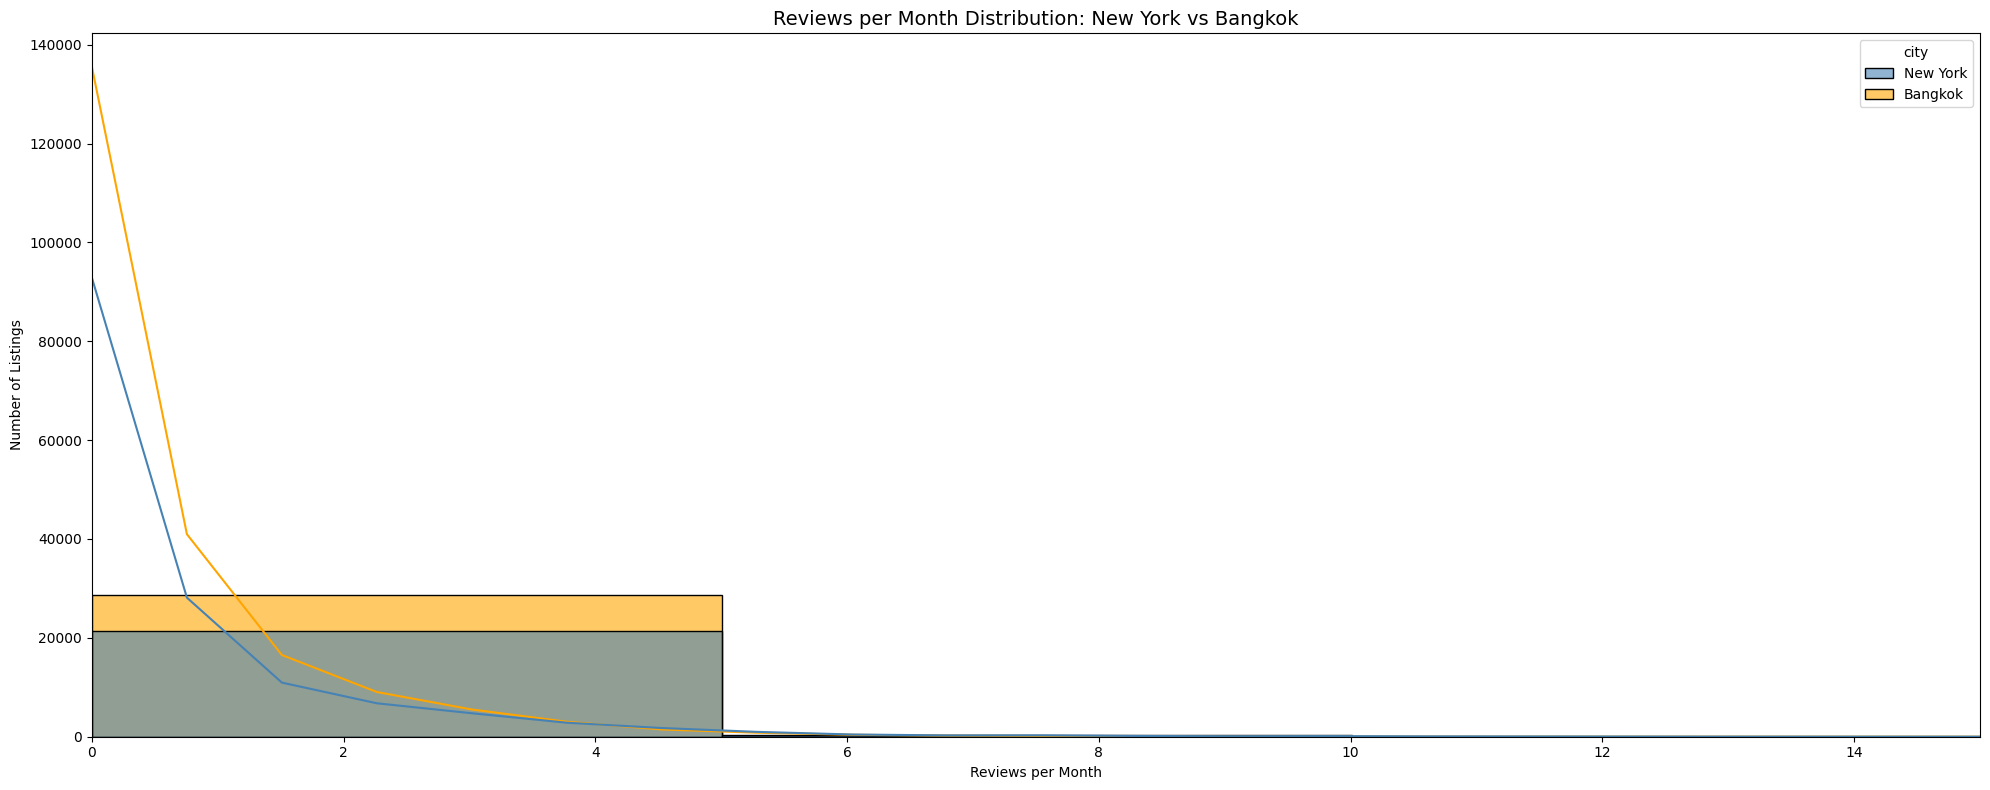


✅ All 6 visualizations complete and saved!


In [25]:
plt.figure(figsize=(20, 8))

sns.histplot(data=combined, x='reviews_per_month', hue='city',
             bins=30, palette={'New York':'steelblue','Bangkok':'orange'},
             alpha=0.6, kde=True)
plt.title('Reviews per Month Distribution: New York vs Bangkok', fontsize=14)
plt.xlabel('Reviews per Month')
plt.ylabel('Number of Listings')
plt.xlim(0, 15)
plt.tight_layout()
plt.savefig('viz6_reviews_distribution.png', dpi=150)
plt.show()
print("\n✅ All 6 visualizations complete and saved!")


In [26]:
# check
print(combined['city'].value_counts())
print(combined['city'].isna().sum())

# fix - make sure city column is correct
ny['city'] = 'New York'
bangkok['city'] = 'Bangkok'

# re-combine
combined = pd.concat([ny, bangkok], ignore_index=True)

# verify
print(combined['city'].value_counts())

# re-export
combined.to_csv(r'c:\Users\hp\Downloads\combined_clean.csv', index=False)
print("✅ Done!")

city
Bangkok     28987
New York    21797
Name: count, dtype: int64
0
city
Bangkok     28987
New York    21797
Name: count, dtype: int64
✅ Done!


In [27]:
print(combined['city'].value_counts())
print(combined['city'].isna().sum())

city
Bangkok     28987
New York    21797
Name: count, dtype: int64
0


In [28]:
# export cleaned data
ny.to_csv(r'c:\Users\hp\Downloads\ny_clean.csv', index=False)
bangkok.to_csv(r'c:\Users\hp\Downloads\bangkok_clean.csv', index=False)
combined.to_csv(r'c:\Users\hp\Downloads\combined_clean.csv', index=False)

print("✅ Files exported successfully!")

✅ Files exported successfully!


In [29]:
combined['city'].unique()

array(['New York', 'Bangkok'], dtype=object)

In [30]:
combined['city'].value_counts()

city
Bangkok     28987
New York    21797
Name: count, dtype: int64

In [31]:
print(28987+21797)

50784


In [32]:
#50785

In [33]:
# strip whitespace and fix
combined['city'] = combined['city'].str.strip()

# remove all nulls and blanks
combined = combined.dropna(subset=['city'])
combined = combined[combined['city'] != '']
combined = combined[combined['city'].isin(['New York', 'Bangkok'])]

# verify
print(combined['city'].value_counts())
print("Total rows:", len(combined))

# re-export
combined.to_csv(r'c:\Users\hp\Downloads\combined_clean.csv', index=False)
print("✅ Done!")

city
Bangkok     28987
New York    21797
Name: count, dtype: int64
Total rows: 50784
✅ Done!
